<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/ESAA_OB_2%EC%A1%B0_Project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **이상신호 감지 기반 비정상작동 진단 분류**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

##데이터 전처리 세팅

In [3]:
train = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/train.csv')
test = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/test.csv')

In [4]:
X_train = train.drop(columns=['ID', 'target'])
y_train = train['target']
X_test = test.drop(columns=['ID'])

###데이터 스케일링

In [5]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

##EDA 및 피처 엔지니어링

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_7681/4159123429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='X_28', data=train, palette='viridis')


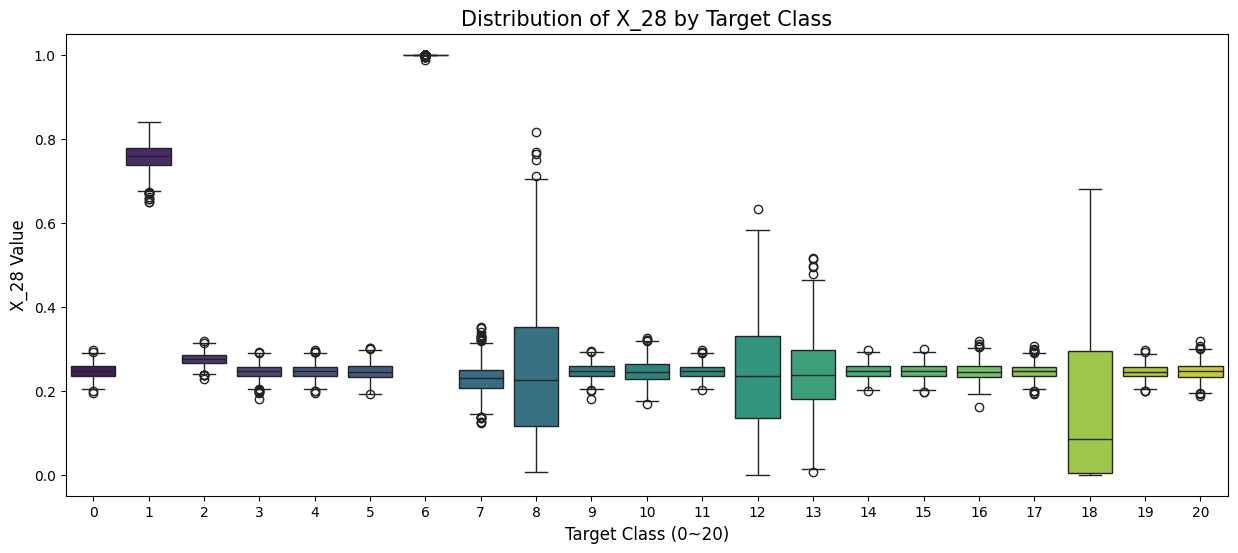

In [7]:
# 타겟별로 상관성이 가장 높았던 X_28 변수의 분포 차이 확인
plt.figure(figsize=(15, 6))
sns.boxplot(x='target', y='X_28', data=train, palette='viridis')
plt.title('Distribution of X_28 by Target Class', fontsize=15)
plt.xlabel('Target Class (0~20)', fontsize=12)
plt.ylabel('X_28 Value', fontsize=12)
plt.show()

###다중공선성 확인 및 중복 변수 제거

In [8]:
redundant_cols = ['X_17', 'X_45']  # X_10과 X_06과 각각 중복됨

X_train_clean = X_train_scaled.drop(columns=redundant_cols)
X_test_clean = X_test_scaled.drop(columns=redundant_cols)
print(f"중복 변수 제거 후 피처 개수: {X_train_clean.shape[1]}개")

중복 변수 제거 후 피처 개수: 50개


###VIF(분산팽창지수) 계산

In [9]:
vif = pd.DataFrame()
vif["Feature"] = X_train_clean.columns
vif["VIF Factor"] = [variance_inflation_factor(X_train_clean.values, i) for i in range(X_train_clean.shape[1])]
print("\n[VIF 상위 5개 변수 - 추가 제거 검토 필요]")
print(vif.sort_values(by="VIF Factor", ascending=False).head(5))


[VIF 상위 5개 변수 - 추가 제거 검토 필요]
   Feature    VIF Factor
48    X_51  15770.777513
4     X_05  13323.617722
36    X_38   1022.458630
23    X_25    896.834701
28    X_30    851.401827


###PCA로 차원 축소


In [10]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_clean)
X_test_pca = pca.transform(X_test_clean)

In [11]:
print(f"\n[PCA 요약]")
print(f"원본 특성 개수(중복제거 후): {X_train_clean.shape[1]}개")
print(f"95% 분산을 설명하는 데 필요한 주성분 개수: {X_train_pca.shape[1]}개")


[PCA 요약]
원본 특성 개수(중복제거 후): 50개
95% 분산을 설명하는 데 필요한 주성분 개수: 18개


In [12]:
pd.DataFrame(X_train_pca).to_csv('train_pca.csv', index=False)

### LightGBM

In [13]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 타겟 및 데이터 설정 (PCA 대신 RF에서 0.77을 기록한 X_train_clean 50개 피처 사용)
num_classes = len(np.unique(y_train))

# Stratified K-Fold 설정 (5-Fold 교차 검증)
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros((X_train_clean.shape[0], num_classes))
test_preds = np.zeros((X_test_clean.shape[0], num_classes))

In [14]:
# LightGBM 하이퍼파라미터 세팅
lgb_params = {
    'objective': 'multiclass',
    'num_class': num_classes,
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 15,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_estimators': 3000,
    'verbosity': -1,
    'n_jobs': -1
}

print("LightGBM K-Fold 학습")

LightGBM K-Fold 학습


In [15]:
# Fold별 학습 및 Soft Voting 앙상블
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train_clean, y_train)):
    X_tr, y_tr = X_train_clean.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_clean.iloc[valid_idx], y_train.iloc[valid_idx]

    model = lgb.LGBMClassifier(**lgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False)
        ]
    )

    # OOF 예측
    oof_preds[valid_idx] = model.predict_proba(X_va)

    # Test 예측 앙상블
    test_preds += model.predict_proba(X_test_clean) / n_splits

In [16]:
# OOF 최종 평가
oof_class_preds = np.argmax(oof_preds, axis=1)
acc = accuracy_score(y_train, oof_class_preds)
macro_f1 = f1_score(y_train, oof_class_preds, average='macro')

print(f"[최종 LightGBM OOF Accuracy]: {acc:.4f}")
print(f"[최종 LightGBM OOF Macro F1 ]: {macro_f1:.4f}")

print("\n[Classification Report]")
print(classification_report(y_train, oof_class_preds))

[최종 LightGBM OOF Accuracy]: 0.7899
[최종 LightGBM OOF Macro F1 ]: 0.7965

[Classification Report]
              precision    recall  f1-score   support

           0       0.22      0.25      0.23      1033
           1       1.00      1.00      1.00      1033
           2       1.00      1.00      1.00      1033
           3       0.45      0.50      0.47      1033
           4       0.99      1.00      0.99      1033
           5       1.00      1.00      1.00      1033
           6       1.00      1.00      1.00      1033
           7       1.00      1.00      1.00      1033
           8       0.98      0.94      0.96      1033
           9       0.18      0.22      0.20      1033
          10       0.80      0.81      0.80      1033
          11       0.98      0.86      0.92      1033
          12       0.93      0.95      0.94      1033
          13       0.99      0.94      0.96      1033
          14       0.85      0.81      0.83      1033
          15       0.20      0.22      

In [17]:
#제출 파일 생성
#final_test_preds = np.argmax(test_preds, axis=1)

#submission = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/test.csv')[['ID']]
#submission['target'] = final_test_preds
#submission.to_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/lgbm_high_performance_submission.csv', index=False)
#print("제출 파일 저장 완료: lgbm_high_performance_submission.csv")

### XGBoost
다중공선성 확인 및 중복 변수 제거 셀에서 만들어진 50개 피처 데이터를 그대로 사용

In [18]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [19]:
# 타겟 클래스 개수
num_classes = len(np.unique(y_train))

# Stratified K-Fold 설정
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# OOF(Out-of Fold) 예측값을 담을 배열
oof_preds = np.zeros((X_train_clean.shape[0], num_classes))
# 5개 fold 모델이 각각 test를 예측한 확률을 누적해서 평균 낼 배열 (soft voting)
test_preds = np.zeros((X_test_clean.shape[0], num_classes))

# XGBoost 하이퍼파라미터 세팅
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.03,
    'max_depth': 7,
    'min_child_weight': 15,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_estimators': 3000,
    'n_jobs': -1,
    'tree_method': 'hist',
    'early_stopping_rounds': 100,   # xgboost 1.6+ sklearn API 기준
}

print("XGBoost K-Fold 학습\n")

XGBoost K-Fold 학습



In [20]:
# Fold별 학습 및 Soft Voting 앙상블
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train_clean, y_train)):
    X_tr, y_tr = X_train_clean.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_clean.iloc[valid_idx], y_train.iloc[valid_idx]

    # 매 fold마다 새로운 모델 생성
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    # OOF 예측
    oof_preds[valid_idx] = model.predict_proba(X_va)
    # Test 예측
    test_preds += model.predict_proba(X_test_clean) / n_splits

    print(f"Fold {fold+1} 완료")

Fold 1 완료
Fold 2 완료
Fold 3 완료
Fold 4 완료
Fold 5 완료


In [21]:
# OOF 최종 평가
oof_class_preds = np.argmax(oof_preds, axis=1)
acc = accuracy_score(y_train, oof_class_preds)
macro_f1 = f1_score(y_train, oof_class_preds, average='macro')

print(f"[최종 XGBoost OOF Accuracy]: {acc:.4f}")
print(f"[최종 XGBoost OOF Macro F1]: {macro_f1:.4f}")
print("\n[Classification Report]")
print(classification_report(y_train, oof_class_preds))

[최종 XGBoost OOF Accuracy]: 0.7921
[최종 XGBoost OOF Macro F1]: 0.7948

[Classification Report]
              precision    recall  f1-score   support

           0       0.22      0.24      0.23      1033
           1       1.00      1.00      1.00      1033
           2       1.00      1.00      1.00      1033
           3       0.51      0.61      0.55      1033
           4       0.98      1.00      0.99      1033
           5       1.00      1.00      1.00      1033
           6       1.00      1.00      1.00      1033
           7       1.00      1.00      1.00      1033
           8       0.98      0.95      0.96      1033
           9       0.17      0.18      0.17      1033
          10       0.74      0.81      0.77      1033
          11       0.96      0.85      0.90      1033
          12       0.94      0.96      0.95      1033
          13       0.98      0.95      0.97      1033
          14       0.82      0.80      0.81      1033
          15       0.21      0.21      0.2

### Random Forest

In [22]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_clean, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train shape: {X_tr.shape}, Validation shape: {X_val.shape}")

Train shape: (17354, 50), Validation shape: (4339, 50)


In [24]:
rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_base.fit(X_tr, y_tr)

val_pred_base = rf_base.predict(X_val)
print("[베이스라인 RF 성능]")
print(f"Accuracy: {accuracy_score(y_val, val_pred_base):.4f}")
print(f"Macro F1: {f1_score(y_val, val_pred_base, average='macro'):.4f}")
print(classification_report(y_val, val_pred_base))

[베이스라인 RF 성능]
Accuracy: 0.7714
Macro F1: 0.7741
              precision    recall  f1-score   support

           0       0.20      0.24      0.21       206
           1       1.00      1.00      1.00       206
           2       1.00      1.00      1.00       207
           3       0.32      0.47      0.38       206
           4       0.98      0.99      0.99       207
           5       1.00      1.00      1.00       206
           6       1.00      1.00      1.00       207
           7       1.00      1.00      1.00       207
           8       0.97      0.95      0.96       206
           9       0.16      0.16      0.16       207
          10       0.73      0.84      0.78       207
          11       0.96      0.86      0.91       206
          12       0.91      0.95      0.93       207
          13       0.99      0.93      0.96       207
          14       0.79      0.75      0.77       207
          15       0.22      0.20      0.21       206
          16       0.67      0.54

In [25]:
from sklearn.model_selection import RandomizedSearchCV

X_tr_sample = X_tr.sample(frac=0.15, random_state=42)
y_tr_sample = y_tr.loc[X_tr_sample.index]

print(f"튜닝용 샘플 크기: {X_tr_sample.shape}")

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_tr_sample, y_tr_sample)

print(f"\n[Best Params]\n{random_search.best_params_}")
print(f"[Best CV Macro F1 (샘플 기준)] {random_search.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
best_rf.fit(X_tr, y_tr)

튜닝용 샘플 크기: (2603, 50)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

[Best Params]
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
[Best CV Macro F1 (샘플 기준)] 0.7030


RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [26]:
val_pred = best_rf.predict(X_val)

print("[튜닝된 RF - Validation 성능]")
print(f"Accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Macro F1: {f1_score(y_val, val_pred, average='macro'):.4f}")
print(classification_report(y_val, val_pred))

[튜닝된 RF - Validation 성능]
Accuracy: 0.7548
Macro F1: 0.7528
              precision    recall  f1-score   support

           0       0.21      0.46      0.29       206
           1       1.00      1.00      1.00       206
           2       1.00      1.00      1.00       207
           3       0.28      0.57      0.37       206
           4       0.98      0.99      0.99       207
           5       1.00      1.00      1.00       206
           6       1.00      1.00      1.00       207
           7       1.00      1.00      1.00       207
           8       0.97      0.95      0.96       206
           9       0.25      0.07      0.11       207
          10       0.60      0.79      0.68       207
          11       0.96      0.83      0.89       206
          12       0.90      0.94      0.92       207
          13       0.99      0.93      0.96       207
          14       0.76      0.65      0.70       207
          15       0.21      0.13      0.16       206
          16       0.6

## 모델 성능 향상+후처리

In [27]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.5 MB/s eta 0:00:00


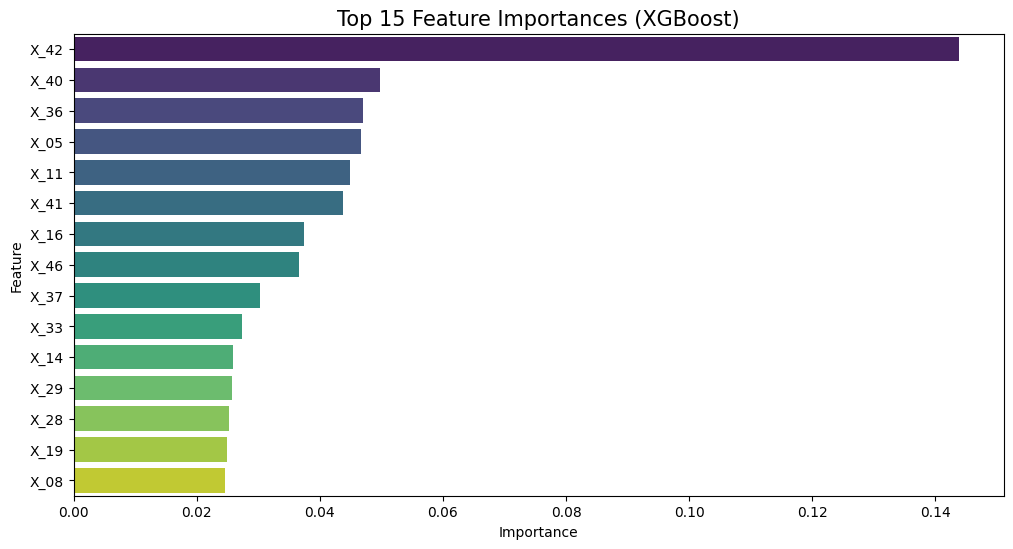

In [28]:
# 모델 성능 향상 + 후처리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import xgboost as xgb
import optuna

# 1. XGBoost 모델 기준 Feature Importance 산출
# 앞선 셀의 K-Fold 루프에서 마지막(5번째) Fold에서 학습된 모델의 중요도
feature_importances = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 중요도 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=15)
plt.show()

In [29]:
# 2. 불필요한 하위 피처 소거 (중요도가 가장 낮은 하위 5개 제거)
low_importance_features = feature_importances.tail(5)['Feature'].tolist()
print(f"[제거 대상 하위 피처]: {low_importance_features}")

X_train_selected = X_train_clean.drop(columns=low_importance_features).copy()
X_test_selected = X_test_clean.drop(columns=low_importance_features).copy()

# 3. 심화 피처 엔지니어링 (상위 5개 중요 피처 간의 상호작용 변수 생성)
top5_features = feature_importances.head(5)['Feature'].tolist()
for i in range(len(top5_features)):
    for j in range(i+1, len(top5_features)):
        f1, f2 = top5_features[i], top5_features[j]
        X_train_selected[f'{f1}_x_{f2}'] = X_train_selected[f1] * X_train_selected[f2]
        X_test_selected[f'{f1}_x_{f2}'] = X_test_selected[f1] * X_test_selected[f2]

print(f"최종 피처 개수: {X_train_selected.shape[1]}개")


# Optuna 하이퍼파라미터 튜닝
def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': num_classes,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'class_weight': 'balanced',
        'random_state': 42,
        'verbosity': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    macro_f1_scores = []

    for train_idx, valid_idx in skf_opt.split(X_train_selected, y_train):
        X_tr, y_tr = X_train_selected.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train_selected.iloc[valid_idx], y_train.iloc[valid_idx]

        model_opt = lgb.LGBMClassifier(**params, n_estimators=500)
        model_opt.fit(
            X_tr, y_tr, eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        preds = model_opt.predict(X_va)
        macro_f1_scores.append(f1_score(y_va, preds, average='macro'))

    return np.mean(macro_f1_scores)

# Optuna 실행
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)
print(f"[Best Optuna Macro F1]: {study.best_value:.4f}")
print(f"[Best Params]:\n{study.best_params}")

[제거 대상 하위 피처]: ['X_06', 'X_03', 'X_23', 'X_10', 'X_01']
최종 피처 개수: 55개
[Best Optuna Macro F1]: 0.8004
[Best Params]:
{'learning_rate': 0.026534075590619922, 'num_leaves': 39, 'max_depth': -1, 'min_child_samples': 32, 'subsample': 0.9284851251464126, 'colsample_bytree': 0.8894145108274869}


In [30]:
# 4. Optuna 최적화 파라미터 적용 및 OOF/Test 재추출
print("\nLightGBM 및 XGBoost OOF/Test 예측값 재추출")

best_lgb_params = lgb_params.copy()
best_lgb_params.update(study.best_params)

oof_lgb = np.zeros((X_train_selected.shape[0], num_classes))
test_lgb = np.zeros((X_test_selected.shape[0], num_classes))

oof_xgb = np.zeros((X_train_selected.shape[0], num_classes))
test_xgb = np.zeros((X_test_selected.shape[0], num_classes))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train_selected, y_train)):
    X_tr, y_tr = X_train_selected.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_selected.iloc[valid_idx], y_train.iloc[valid_idx]

    # LightGBM 학습
    model_lgb = lgb.LGBMClassifier(**best_lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])
    oof_lgb[valid_idx] = model_lgb.predict_proba(X_va)
    test_lgb += model_lgb.predict_proba(X_test_selected) / n_splits

    # XGBoost 학습
    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_xgb[valid_idx] = model_xgb.predict_proba(X_va)
    test_xgb += model_xgb.predict_proba(X_test_selected) / n_splits

# 5. 최적의 Blending 가중치 탐색
print("최적의 앙상블 가중치 탐색 (LGBM vs XGBoost)")
best_weight = 0.5
best_macro_f1 = 0

for w in np.arange(0.0, 1.05, 0.05):
    blend_oof_probs = (w * oof_lgb) + ((1 - w) * oof_xgb)
    blend_preds = np.argmax(blend_oof_probs, axis=1)

    current_f1 = f1_score(y_train, blend_preds, average='macro')
    if current_f1 > best_macro_f1:
        best_macro_f1 = current_f1
        best_weight = w

print(f"최적 가중치: LightGBM {best_weight:.2f} : XGBoost {1 - best_weight:.2f}")
print(f"앙상블 적용 후 OOF Macro F1: {best_macro_f1:.4f}")

final_oof_probs = (best_weight * oof_lgb) + ((1 - best_weight) * oof_xgb)
final_test_probs = (best_weight * test_lgb) + ((1 - best_weight) * test_xgb)


LightGBM 및 XGBoost OOF/Test 예측값 재추출
최적의 앙상블 가중치 탐색 (LGBM vs XGBoost)
최적 가중치: LightGBM 0.65 : XGBoost 0.35
앙상블 적용 후 OOF Macro F1: 0.8050


In [31]:
# 6. 취약 클래스 임계값 동적 조정 (최적 Multiplier 탐색)
print("(최적 가중치 탐색 후처리 적용)")
weak_classes = [0, 3, 9, 15, 19]

best_multiplier = 1.0
best_post_f1 = best_macro_f1

for m in np.arange(1.0, 2.05, 0.05):
    temp_oof_probs = final_oof_probs.copy()

    for c in weak_classes:
        temp_oof_probs[:, c] *= m

    temp_preds = np.argmax(temp_oof_probs, axis=1)
    temp_f1 = f1_score(y_train, temp_preds, average='macro')

    if temp_f1 > best_post_f1:
        best_post_f1 = temp_f1
        best_multiplier = m

print(f"탐색된 취약 클래스 최적 증폭 비율: {best_multiplier:.2f}배")
print(f"후처리 적용 후 최종 OOF Macro F1: {best_post_f1:.4f}")

post_processed_test_probs = final_test_probs.copy()
for c in weak_classes:
    post_processed_test_probs[:, c] *= best_multiplier

final_test_preds = np.argmax(post_processed_test_probs, axis=1)

(최적 가중치 탐색 후처리 적용)
탐색된 취약 클래스 최적 증폭 비율: 1.20배
후처리 적용 후 최종 OOF Macro F1: 0.8051


In [36]:
# 7. 제출 파일 생성
submission = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/test.csv')[['ID']]
submission['target'] = final_test_preds
submission_path = '/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/final_ensemble_submission.csv'
submission.to_csv(submission_path, index=False)
print(f"최종 제출 파일 저장 완료: {submission_path}")

최종 제출 파일 저장 완료: /content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/final_ensemble_submission.csv
